<a href="https://colab.research.google.com/github/kya6/Cinsight/blob/main/Cinsight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Customer Complaint Escalation**
**Prediction**    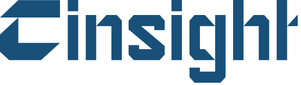

by

Mohammad Alkhayat

Luluh Almasoud

Wafa Mohammed

Shouq Qahl

# Importing the needed libraries





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1-Data Cleaning

Loading The Dataset

In [ ]:
# قراءة الملف المرفوع مباشرة في Colab
file_path = '/content/complaints-2026-08-26_02_56.csv'

df = pd.read_csv(file_path, on_bad_lines='skip', engine='python')

In [ ]:
df = pd.read_csv('/content/complaints-2026-08-26_02_56.csv')

ParserError: Error tokenizing data. C error: Expected 16 fields in line 159, saw 32


In [ ]:
# Explore the data, WIll be Display the first 5 Rows
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,I can not get needed information about out my ...,although I have tried repeatedly by every ven...,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,When I access my account online,the only info that is presented is current am...,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [ ]:

#Check the columns
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359645 entries, 0 to 359644
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Date received                 359638 non-null  object
 1   Product                       123685 non-null  object
 2   Sub-product                   84623 non-null   object
 3   Issue                         54025 non-null   object
 4   Sub-issue                     34026 non-null   object
 5   Consumer complaint narrative  22170 non-null   object
 6   Company public response       10663 non-null   object
 7   Company                       11622 non-null   object
 8   State                         9621 non-null    object
 9   ZIP code                      8528 non-null    object
 10  Tags                          2231 non-null    object
 11  Submitted via                 7336 non-null    object
 12  Date sent to company          7008 non-null    object
 13 

In [ ]:

#check the shape of DataFram (row's,columns)
df.shape


(359645, 16)

In [ ]:
# Count values in Product column
df['Product'].value_counts()


,count
Product,
Debt collection,2573
Checking or savings account,1904
Credit card,992
XXXX,823
Vehicle loan or lease,356
...,...
I can reach XXXX,1
I have made multiple attempts to contact XXXX directly to resolve or verify this issue. However,1
I received an email from XXXX XXXX XXXX stating that my account was closed. I had no further contact from XXXX no emails,1


In [ ]:
# Count values in Issue column
df['Issue'].value_counts()


,count
Issue,
Attempts to collect debt not owed,1562
Managing an account,986
XXXX,346
Problem with a lender or other company charging your account,328
Took or threatened to take negative or legal action,273
...,...
Huntingtons systems were in receipt of the restriction before any subsequent outreach. Under 12 C.F.R. 1006.6 ( c ) ( 1 ),1
as well as the OCCs unfair practices authority.;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;,1
cleared first which makes no logical or regulatory sense. This inconsistency demonstrates a failure to follow Regulation CC ( 12 CFR Part 229 ) and Bank of Americas own Funds Availability Policy,1


In [ ]:
# Count values in State column
df['State'].value_counts()


,count
State,
TX,628
CA,592
FL,587
GA,473
IL,425
...,...
documents provided and filed with the Secretary of State showing that it is a legitimate business,1
uploaded the dollar and cents EXACT AMOUNT and see if they could force take the payment that way. By XXXX XXXX that same Monday,1
favorable client,1


In [ ]:
# Count values in Submitted via column
df['Submitted via'].value_counts()


,count
Submitted via,
Web,6468
Yes,61
Closed with explanation,40
and parties involved in every assignment or sale. ;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;,10
and legally incapable of alteration or rebuttal by any party,8
...,...
or proper legal process. At the time of the XXXX,1
I was incorrectly told that I had sent the wire transfer incorrectly. The representatives dismissive attitude essentially too bad only heightened my anxiety over whether {$45000.00} had disappeared into a financial black hole. ;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;,1
XXXX XXXX XXXX XXXX ),1


In [ ]:
# Count values in Tags column
df['Tags'].value_counts()


,count
Tags,
Servicemember,530
Older American,306
Yes,95
Closed with explanation,54
Web,17
...,...
discharging the debt unless the creditor proves non-payment or dishonor. Similarly,1
the principal balance had barely moved,1
2025-10-24T02:00:50.000Z,1


In [ ]:
df.describe(include='object')

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
count,359638,123685,84623,54025,34026,22170,10663,11622,9621,8528,2231,7336,7008,6792,6622,6516
unique,151302,98626,66078,40327,23916,19409,7596,4786,2623,4651,1107,698,6873,294,145,6515
top,;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...,Debt collection,Checking account,Attempts to collect debt not owed,Debt was result of identity theft,XXXX,Company has responded to the consumer and the ...,Chime Financial Inc,TX,XXXXX,Servicemember,Web,Yes,Closed with explanation,Yes,for the following reasons : I am not the pers...
freq,173890,2573,1628,1562,991,137,1432,648,628,114,530,6468,42,5353,6278,2


In [ ]:
#Convert the "Date received" column from text to datetime format.
df['Date received'] = pd.to_datetime(df['Date received'], utc=True)
#Check the data type to make sure the conversion was successful.
df['Date received'].dtype

/tmp/ipykernel_1080/4161758199.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date received'] = pd.to_datetime(df['Date received'], utc=True)


DateParseError: Unable to parse datetime string: ;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;, at position 0

In [ ]:
#Drop columns that are not needed for our analysis or may introduce
#post-submission information, identifiers, or unnecessary details.
df = df.drop(columns=[ 'Timely response?', 'Company public response', 'Date sent to company', 'Complaint ID', 'Submitted via', 'ZIP code' ])

KeyError: "['Timely response?', 'Company public response', 'Date sent to company', 'Complaint ID', 'Submitted via', 'ZIP code'] not found in axis"

In [ ]:
df.shape

(81886, 10)

In [ ]:
#Display the remaining columns to verify that the selected columns were removed.
df.columns

The dataset contains many unique categories, with Debt collection being the most common product and Texas being the most common state.

#**Checking if there are any missing values**

In [ ]:

#Check if duplicated in data
df.duplicated().sum()

In [ ]:

#Get the sum of null values
df.isnull().sum()

The dataset contains missing values in four columns, with Tags having the most missing values

In [ ]:
# Define the columns to be dropped
cols_to_drop = ['Submitted via', 'Company public response', 'ZIP code']

# Drop the specified columns from the dataframe
df.drop(columns=cols_to_drop, inplace=True)

# Verify the updated shape of the dataframe
print("Updated dataset shape:", df.shape)

Updated dataset shape: (81886, 13)
